In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:33475")
client

<Client: 'tcp://127.0.0.1:33475' processes=10 threads=80, memory=80.00 GiB>

Task exception was never retrieved
future: <Task finished name='Task-2507' coro=<Client._gather.<locals>.wait() done, defined at /app/nepcon/miniconda3/envs/py312/lib/python3.12/site-packages/distributed/client.py:2385> exception=AllExit()>
Traceback (most recent call last):
  File "/app/nepcon/miniconda3/envs/py312/lib/python3.12/site-packages/distributed/client.py", line 2394, in wait
    raise AllExit()
distributed.client.AllExit


In [2]:
import numpy as np
import xarray as xr
import os.path as op
from xgcm.grid import Grid

import xrft

# from xmovie import Movie

import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
ddir = "/app/Oceananigans/"
bdir = "/app/Oceananigans/barotropic/"

In [4]:
dt = 20.
f0 = 1e-4

iiter = 4
# ds = xr.open_zarr(op.join(ddir, 
#             "ocean_wind_mixing_and_convection/bottom-drag/Z1km/"
#             + "384x384x64/Q200/output.%04d.zarr" % iiter
#                          )
#                  )
ds = xr.open_dataset(op.join(ddir, 
                     "ocean_wind_mixing_and_convection/"
                     + "bottom-drag/Z2km/512x512x64/Q200/spinup.%04d.nc"
                             % iiter
                            ),
                     chunks={"z_aaf":-1,"z_aac":-1,
                             "y_afa":64,"x_faa":64,
                             "x_caa":64,"y_aca":64
                            }
     )

grid = Grid(ds, 
            periodic=['X', 'Y'], autoparse_metadata=False,
            coords={'X': {'left': 'x_faa', 'center': 'x_caa'},
                    'Y': {'left': 'y_afa', 'center': 'y_aca'},
                    'Z': {'center': 'z_aac', 'outer': 'z_aaf'}
                   }
           )
gridz = Grid(ds, periodic=False, autoparse_metadata=False,
             coords={'X': {'left': 'x_faa', 'center': 'x_caa'},
                     'Y': {'left': 'y_afa', 'center': 'y_aca'},
                     'Z': {'center': 'z_aac', 'outer': 'z_aaf'}
                    }
            )
ds, grid

/tmp/ipykernel_2631/3971319027.py:10: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(op.join(ddir,
/tmp/ipykernel_2631/3971319027.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "y_aca" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(op.join(ddir,
/tmp/ipykernel_2631/3971319027.py:10: UserWarning: The specified chunks separate the stored chunks along dimen

(<xarray.Dataset> Size: 9GB
 Dimensions:  (x_caa: 512, x_faa: 512, y_aca: 512, y_afa: 512, z_aac: 64,
               z_aaf: 65, time: 27)
 Coordinates:
   * time     (time) timedelta64[ns] 216B 640 days 650 days ... 890 days 900 days
   * y_afa    (y_afa) float32 2kB -1e+05 -9.961e+04 ... 9.922e+04 9.961e+04
   * x_faa    (x_faa) float32 2kB 0.0 390.6 781.2 ... 1.992e+05 1.996e+05
   * x_caa    (x_caa) float32 2kB 195.3 585.9 976.6 ... 1.994e+05 1.998e+05
   * y_aca    (y_aca) float32 2kB -9.98e+04 -9.941e+04 ... 9.941e+04 9.98e+04
   * z_aaf    (z_aaf) float32 260B -2e+03 -1.664e+03 -1.407e+03 ... -10.02 0.0
   * z_aac    (z_aac) float32 256B -1.832e+03 -1.536e+03 ... -15.02 -5.008
 Data variables:
     Δx_caa   (x_caa) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
     Δx_faa   (x_faa) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
     Δy_aca   (y_aca) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
     Δy_afa   (y_afa) float32 2kB dask.array<chunksize

In [22]:
ds.isel(z_aac=23)

<xarray.Dataset> Size: 2GB
Dimensions:  (x_caa: 512, x_faa: 512, y_aca: 512, y_afa: 512, z_aaf: 65,
              time: 27)
Coordinates:
  * time     (time) timedelta64[ns] 216B 640 days 650 days ... 890 days 900 days
  * y_afa    (y_afa) float32 2kB -1e+05 -9.961e+04 ... 9.922e+04 9.961e+04
  * x_faa    (x_faa) float32 2kB 0.0 390.6 781.2 ... 1.992e+05 1.996e+05
  * x_caa    (x_caa) float32 2kB 195.3 585.9 976.6 ... 1.994e+05 1.998e+05
  * y_aca    (y_aca) float32 2kB -9.98e+04 -9.941e+04 ... 9.941e+04 9.98e+04
  * z_aaf    (z_aaf) float32 260B -2e+03 -1.664e+03 -1.407e+03 ... -10.02 0.0
    z_aac    float32 4B -407.8
Data variables:
    Δx_caa   (x_caa) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
    Δx_faa   (x_faa) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
    Δy_aca   (y_aca) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
    Δy_afa   (y_afa) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
    Δz_aac   float32 4B dask.array<chunksize=(), meta=np.ndarray>
    Δz_aaf   (z_aaf) float32 260B dask.array<chunksize=(65,), meta=np.ndarray>
    b        (time, y_aca, x_caa) float32 28MB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>
    e        (time, y_aca, x_caa) float32 28MB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>
    u        (time, y_aca, x_faa) float32 28MB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>
    v        (time, y_afa, x_caa) float32 28MB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>
    w        (time, z_aaf, y_aca, x_caa) float32 2GB dask.array<chunksize=(1, 65, 64, 64), meta=np.ndarray>
Attributes:
    Julia:                 This file was generated using CUDA GPU: NVIDIA GeF...
    Oceananigans:          This file was generated using Oceananigans v0.100.7
    date:                  This file was generated on 2026-02-22T16:07:43.346...
    interval:              864000.0
    output time interval:  Output was saved every 10 days.
    schedule:              TimeInterval

In [5]:
dspp = xr.open_zarr(op.join(ddir, 
                "ocean_wind_mixing_and_convection/bottom-drag/Z2km/"
                + "512x512x64/Q200/spinup/Upp.%04d.zarr" % iiter
                           )
                   )
dspp

<xarray.Dataset> Size: 13GB
Dimensions:  (y_aca: 512, x_caa: 512, z_aac: 64, time: 27, x_faa: 512,
              y_afa: 512, z_aaf: 65)
Coordinates:
  * time     (time) timedelta64[ns] 216B 640 days 650 days ... 890 days 900 days
  * x_caa    (x_caa) float32 2kB 195.3 585.9 976.6 ... 1.994e+05 1.998e+05
  * x_faa    (x_faa) float32 2kB 0.0 390.6 781.2 ... 1.992e+05 1.996e+05
  * y_aca    (y_aca) float32 2kB -9.98e+04 -9.941e+04 ... 9.941e+04 9.98e+04
  * y_afa    (y_afa) float32 2kB -1e+05 -9.961e+04 ... 9.922e+04 9.961e+04
  * z_aac    (z_aac) float32 256B -1.832e+03 -1.536e+03 ... -15.02 -5.008
  * z_aaf    (z_aaf) float32 260B -2e+03 -1.664e+03 -1.407e+03 ... -10.02 0.0
Data variables:
    bhash    (y_aca, x_caa, z_aac) float64 134MB dask.array<chunksize=(512, 512, 1), meta=np.ndarray>
    Piflat   (time, y_aca, x_caa, z_aac) float64 4GB dask.array<chunksize=(1, 512, 512, 1), meta=np.ndarray>
    Pip      (time, y_aca, x_caa, z_aac) float64 4GB dask.array<chunksize=(1, 512, 512, 1), meta=np.ndarray>
    upp      (time, y_aca, x_faa, z_aac) float32 2GB dask.array<chunksize=(1, 512, 512, 1), meta=np.ndarray>
    vpp      (time, y_afa, x_caa, z_aac) float32 2GB dask.array<chunksize=(1, 512, 512, 1), meta=np.ndarray>
    wflat    (time, y_aca, x_caa, z_aaf) float32 2GB dask.array<chunksize=(1, 512, 512, 1), meta=np.ndarray>

In [6]:
up = (ds.u - ds.u.mean("time")
     ).chunk({"z_aac":1,"y_aca":-1,"x_faa":-1})
vp = (ds.v - ds.v.mean("time")
     ).chunk({"z_aac":1,"y_afa":-1,"x_caa":-1})
wp = (ds.w - ds.w.mean("time")
     ).chunk({"z_aaf":-1,"y_aca":-1, "x_caa":-1})

In [25]:
izc = 23

In [26]:
Fup = xrft.isotropic_power_spectrum(up, 
                                    dim=["y_aca","x_faa"], detrend="constant", 
                                    truncate=True
                                   )
Fvp = xrft.isotropic_power_spectrum(vp, 
                                    dim=["y_afa","x_caa"], detrend="constant", 
                                    truncate=True
                                   )
Fupp = xrft.isotropic_power_spectrum(dspp.upp.isel(z_aac=izc), 
                                     dim=["y_aca","x_faa"], detrend="constant", 
                                     truncate=True
                                    )
Fvpp = xrft.isotropic_power_spectrum(dspp.vpp.isel(z_aac=izc), 
                                     dim=["y_afa","x_caa"], detrend="constant", 
                                     truncate=True
                                    )
Ep = .5*(Fup + Fvp)
Epp = .5*(Fupp + Fvpp)
Ep, Epp

(<xarray.DataArray (time: 27, z_aac: 64, freq_r: 90)> Size: 1MB
 dask.array<mul, shape=(27, 64, 90), dtype=float64, chunksize=(1, 1, 90), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) timedelta64[ns] 216B 640 days 650 days ... 890 days 900 days
   * z_aac    (z_aac) float32 256B -1.832e+03 -1.536e+03 ... -15.02 -5.008
   * freq_r   (freq_r) float64 720B 9.372e-06 2.2e-05 ... 0.001251 0.001266,
 <xarray.DataArray (time: 27, freq_r: 90)> Size: 19kB
 dask.array<mul, shape=(27, 90), dtype=float64, chunksize=(1, 90), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) timedelta64[ns] 216B 640 days 650 days ... 890 days 900 days
     z_aac    float32 4B -407.8
   * freq_r   (freq_r) float64 720B 9.372e-06 2.2e-05 ... 0.001251 0.001266)

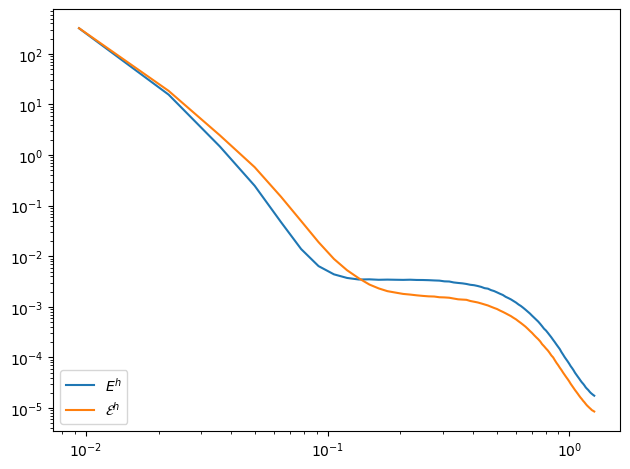

In [27]:
fig, ax = plt.subplots()
fig.set_tight_layout(True)
ax.plot(Ep.freq_r*1e3, Ep.isel(z_aac=izc).mean("time"), label=r"$E^h$")
ax.plot(Epp.freq_r*1e3, Epp.mean("time"), label=r"$\mathcal{E}^h$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(loc="lower left")
ax.grid(True)

In [28]:
Fwp = xrft.isotropic_power_spectrum(wp.chunk({"z_aaf":1,"y_aca":-1,"x_caa":-1}), 
                                    dim=["y_aca","x_caa"], detrend="constant", 
                                    truncate=True
                                   )
Fws = xrft.isotropic_power_spectrum(dspp.wflat.isel(z_aaf=izc), 
                                    dim=["y_aca","x_caa"], detrend="constant", 
                                    truncate=True
                                   )
Fwp, Fws

(<xarray.DataArray (time: 27, z_aaf: 65, freq_r: 90)> Size: 1MB
 dask.array<getitem, shape=(27, 65, 90), dtype=float64, chunksize=(1, 1, 90), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) timedelta64[ns] 216B 640 days 650 days ... 890 days 900 days
   * z_aaf    (z_aaf) float32 260B -2e+03 -1.664e+03 -1.407e+03 ... -10.02 0.0
   * freq_r   (freq_r) float64 720B 9.372e-06 2.2e-05 ... 0.001251 0.001266,
 <xarray.DataArray (time: 27, freq_r: 90)> Size: 19kB
 dask.array<getitem, shape=(27, 90), dtype=float64, chunksize=(1, 90), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) timedelta64[ns] 216B 640 days 650 days ... 890 days 900 days
     z_aaf    float32 4B -413.1
   * freq_r   (freq_r) float64 720B 9.372e-06 2.2e-05 ... 0.001251 0.001266)

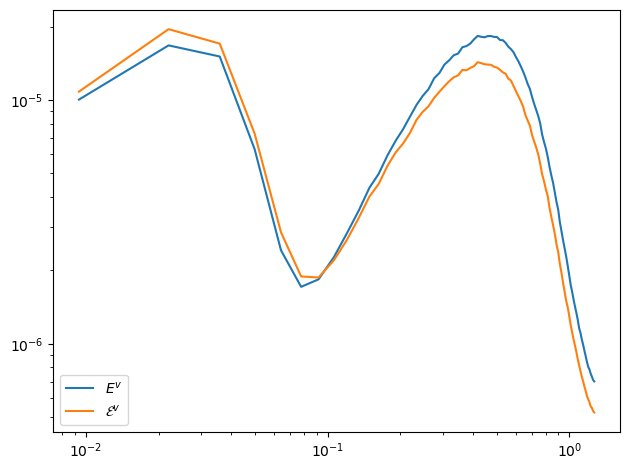

In [29]:
fig, ax = plt.subplots()
fig.set_tight_layout(True)
ax.plot(Fwp.freq_r*1e3, Fwp.isel(z_aaf=izc).mean("time"), label=r"$E^v$")
ax.plot(Fws.freq_r*1e3, Fws.mean("time"), label=r"$\mathcal{E}^v$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(loc="lower left")

In [30]:
Zp = xrft.isotropic_power_spectrum(dspp.Pip.isel(z_aac=izc).chunk({"y_aca":-1,"x_caa":-1}), 
                                   dim=["y_aca","x_caa"], detrend="constant", 
                                   truncate=True
                                  )
Zs = xrft.isotropic_power_spectrum(dspp.Piflat.isel(z_aac=izc).chunk({"y_aca":-1,"x_caa":-1}), 
                                   dim=["y_aca","x_caa"], detrend="constant", 
                                   truncate=True
                                  )
Zp, Zs

(<xarray.DataArray (time: 27, freq_r: 90)> Size: 19kB
 dask.array<getitem, shape=(27, 90), dtype=float64, chunksize=(1, 90), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) timedelta64[ns] 216B 640 days 650 days ... 890 days 900 days
     z_aac    float32 4B -407.8
   * freq_r   (freq_r) float64 720B 9.372e-06 2.2e-05 ... 0.001251 0.001266,
 <xarray.DataArray (time: 27, freq_r: 90)> Size: 19kB
 dask.array<getitem, shape=(27, 90), dtype=float64, chunksize=(1, 90), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) timedelta64[ns] 216B 640 days 650 days ... 890 days 900 days
     z_aac    float32 4B -407.8
   * freq_r   (freq_r) float64 720B 9.372e-06 2.2e-05 ... 0.001251 0.001266)

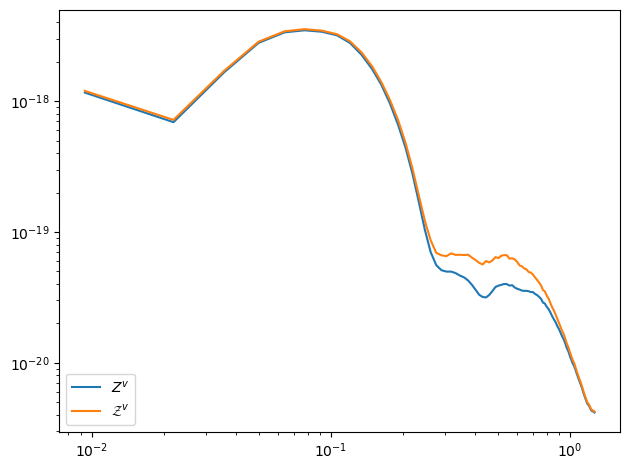

In [31]:
fig, ax = plt.subplots()
fig.set_tight_layout(True)
ax.plot(Zp.freq_r*1e3, Zp.mean("time"), label=r"$Z^v$")
ax.plot(Zs.freq_r*1e3, Zs.mean("time"), label=r"$\mathcal{Z}^v$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(loc="lower left")
ax.grid(True)

In [13]:
bp = (ds.b - ds.b.mean("time")).chunk({"y_aca":-1, "x_caa":-1})
bflat = (ds.b - dspp.bhash).chunk({"y_aca":-1, "x_caa":-1})
bflat

/app/nepcon/miniconda3/envs/py312/lib/python3.12/site-packages/dask/array/core.py:5003: PerformanceWarning: Increasing number of chunks by factor of 64
  result = blockwise(


<xarray.DataArray (time: 27, z_aac: 64, y_aca: 512, x_caa: 512)> Size: 4GB
dask.array<rechunk-merge, shape=(27, 64, 512, 512), dtype=float64, chunksize=(1, 1, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) timedelta64[ns] 216B 640 days 650 days ... 890 days 900 days
  * x_caa    (x_caa) float32 2kB 195.3 585.9 976.6 ... 1.994e+05 1.998e+05
  * y_aca    (y_aca) float32 2kB -9.98e+04 -9.941e+04 ... 9.941e+04 9.98e+04
  * z_aac    (z_aac) float32 256B -1.832e+03 -1.536e+03 ... -15.02 -5.008

In [14]:
(iks, ike) = (3,izc+1)
for ik in range(iks,ike):
    if ik == iks:
        Cp = xrft.isotropic_cross_spectrum(grid.interp(wp,"Z",boundary="extend"
                                                      ).isel(z_aac=ik),
                                           bp.isel(z_aac=ik),
                                           dim=["y_aca","x_caa"], detrend="constant", 
                                           truncate=True
                                          ).real
        Cf = xrft.isotropic_cross_spectrum(grid.interp(dspp.wflat.chunk({"z_aaf":-1}),
                                                       "Z",boundary="extend"
                                                      ).isel(z_aac=ik),
                                           bflat.isel(z_aac=ik),
                                           dim=["y_aca","x_caa"], detrend="constant", 
                                           truncate=True
                                          ).real
    else:
        Cp = xr.concat([Cp,
                        xrft.isotropic_cross_spectrum(grid.interp(wp,"Z",
                                                                  boundary="extend"
                                                                 ).isel(z_aac=ik),
                                                      bp.isel(z_aac=ik),
                                                      dim=["y_aca","x_caa"], 
                                                      detrend="constant", 
                                                      truncate=True
                                                     ).real
                       ], "z_aac")
        Cf = xr.concat([Cf,
                        xrft.isotropic_cross_spectrum(grid.interp(dspp.wflat.chunk({"z_aaf":-1}),
                                                                  "Z", boundary="extend"
                                                                 ).isel(z_aac=ik),
                                                      bflat.isel(z_aac=ik),
                                                      dim=["y_aca","x_caa"], 
                                                      detrend="constant", 
                                                      truncate=True
                                                     ).real
                       ], "z_aac")
Cp.coords["z_aac"] = ds.z_aac.isel(z_aac=slice(iks,ike))
Cf.coords["z_aac"] = ds.z_aac.isel(z_aac=slice(iks,ike))
Cp, Cf

/app/nepcon/miniconda3/envs/py312/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 17.00 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/app/nepcon/miniconda3/envs/py312/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 17.00 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/app/nepcon/miniconda3/envs/py312/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 17.00 MiB.
T

(<xarray.DataArray (z_aac: 31, time: 27, freq_r: 90)> Size: 603kB
 dask.array<concatenate, shape=(31, 27, 90), dtype=float64, chunksize=(1, 1, 90), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) timedelta64[ns] 216B 640 days 650 days ... 890 days 900 days
   * freq_r   (freq_r) float64 720B 9.372e-06 2.2e-05 ... 0.001251 0.001266
   * z_aac    (z_aac) float32 124B -1.132e+03 -995.7 -889.8 ... -315.7 -305.6,
 <xarray.DataArray (z_aac: 31, time: 27, freq_r: 90)> Size: 603kB
 dask.array<concatenate, shape=(31, 27, 90), dtype=float64, chunksize=(1, 1, 90), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) timedelta64[ns] 216B 640 days 650 days ... 890 days 900 days
   * freq_r   (freq_r) float64 720B 9.372e-06 2.2e-05 ... 0.001251 0.001266
   * z_aac    (z_aac) float32 124B -1.132e+03 -995.7 -889.8 ... -315.7 -305.6)

/app/nepcon/miniconda3/envs/py312/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 21.57 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/app/nepcon/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/app/nepcon/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


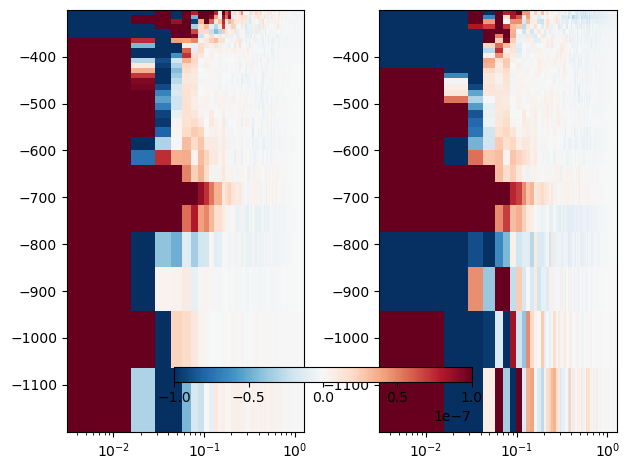

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2)
fig.set_tight_layout(True)
im = axes[0].pcolormesh(Cp.freq_r*1e3, Cp.z_aac, Cp.mean("time"),
              vmax=1e-7, vmin=-1e-7, cmap="RdBu_r",
              rasterized=True)
axes[1].pcolormesh(Cf.freq_r*1e3, Cf.z_aac, Cf.mean("time"),
              vmax=1e-7, vmin=-1e-7, cmap="RdBu_r",
              rasterized=True)
axes[0].set_xscale("log")
axes[1].set_xscale("log")
# ax.legend(loc="lower left")
fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)

/app/nepcon/miniconda3/envs/py312/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 25.93 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


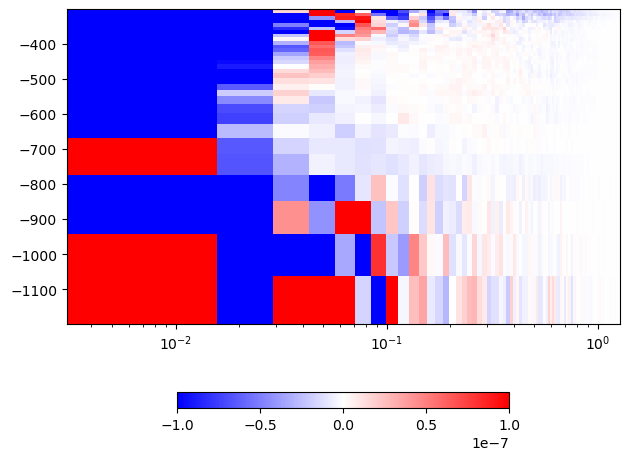

In [16]:
fig, ax = plt.subplots()
fig.set_tight_layout(True)
im = ax.pcolormesh(Cp.freq_r*1e3, Cp.z_aac, 
                   Cf.mean("time") - Cp.mean("time"),
                   vmax=1e-7, vmin=-1e-7, cmap="bwr",
                   rasterized=True)
ax.set_xscale("log")
# ax.legend(loc="lower left")
fig.colorbar(im, ax=ax, orientation="horizontal", shrink=.6)